In [1]:
import torch
import numpy as np
import time
import pickle

import hockey.hockey_env as h_env

from sac.plots import *
from sac.utils import from_dict, SB3_PARAMS, get_trained_agent, create_agent, save_logs
from sac.trainer import HockeyTrainer, SCORE_REWARD, DEFAULT_REWARD, ACTION_BOUNDS, SCALING
from sac.tournament import PooledTournament, LowMemTournament, MixedTournament

In [2]:
params = SB3_PARAMS
hidden_sizes = [256, 256]
params["alpha"] = 1.
params["lr"] = 3e-4
params["hl_bounds"] = [-30, 11]
params["hidden_sizes"] = hidden_sizes
params["action_bounds"] = ACTION_BOUNDS
params["obs_scale"] = SCALING
params["hl"] = True

In [3]:
random_seed = 0

In [4]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [5]:
filepath = f"./results/hl-{random_seed}"

In [ ]:
# start_ep = 0
# agent = create_agent(**params)
start_ep = 6212
agent = get_trained_agent(f"../agents/{start_ep}.pth", params)

In [ ]:
trainer = HockeyTrainer(agent, reward_func=DEFAULT_REWARD, start_ep=start_ep)
weak_opponent = h_env.BasicOpponent(weak=True)
strong_opponent = h_env.BasicOpponent(weak=False)

In [7]:
bot_tournament = PooledTournament(seed=random_seed)
bot_tournament.add_agent(weak_opponent)
bot_tournament.add_agent(strong_opponent)

In [ ]:
agent_paths = [
    # "../agents/strong-0-7000.pth",
    # "../agents/strongcont-0-5500.pth",
    # "../agents/adaptive-0-1500.pth",
    # "../agents/500.pth"
]
agent_paths_hl = [
    # "../agents/1400.pth",
    # "../agents/2300.pth",
    # "../agents/selfplay-hl-4400.pth",
]

agent_tournament = LowMemTournament(seed=random_seed)
test_params = params.copy()
test_params["hl"] = False
for agent_path in agent_paths:
    agent_tournament.add_agent(agent_path, test_params)
for agent_path in agent_paths_hl:
    agent_tournament.add_agent(agent_path, params)



In [21]:
pbot = 0.3
tournament = MixedTournament([bot_tournament, agent_tournament], [pbot, 1-pbot], seed=random_seed)

In [10]:
trainer.warmup(10000, tournament=tournament)

In [11]:
max_timesteps = 500
new_episodes = 100
log_interval = 20
train_interval = 2

In [10]:
def evaluate_agent(trainer, opponent=None, tournament=None, n=100):
    rewards, scores = trainer.evaluate(opponent=opponent, tournament=tournament, episodes=n, render=False)
    winrate = 0.5 * (np.mean(scores)+1)
    print("Avg reward:",np.mean(rewards))
    print("Winrate:",0.5 * (np.mean(scores)+1))
    print("Winrate (no ties):", np.mean(np.asarray(scores) == 1))
    return winrate

In [ ]:
def add_agent(trainer, tournament, params):
    new_agent = create_agent(**params)
    agent_state = trainer.agent.state()
    new_agent.restore_state(agent_state)
    tournament.add_agent(new_agent)

In [18]:
bot_target = 0.
max_bot_target = 0.7
agent_target = 0.55
# max_agent_target = 0.55
n = 100

In [15]:
prev_opp = create_agent(**params)
prev_opp.restore_state(trainer.agent.state())

In [ ]:
for i in range(10):
    trainer.train(tournament, new_episodes, train_interval, log_interval, max_timesteps)
    weak_winrate = evaluate_agent(trainer, opponent=weak_opponent, n=n)
    strong_winrate = evaluate_agent(trainer, opponent=strong_opponent, n=n)
    prev_winrate = evaluate_agent(trainer, opponent=prev_opp, n=n)
    if weak_winrate >= bot_target and strong_winrate >= bot_target and prev_winrate >= agent_target:
        trainer.save_agent(filepath)
        agent_tournament.add_agent(f'{filepath}/{trainer.episode}.pth', params)
        prev_opp.restore_state(trainer.agent.state())
        bot_target = min(max_bot_target, 0.9*weak_winrate, 0.9*strong_winrate)
        # agent_target = min(max_agent_target, prev_winrate)
        print("UPDATED!")
        
    else:
        trainer.agent.restore_state(prev_opp.state())
        trainer.reset_logs()

  1020: Reward:    1.500 Winrate:    0.575
  1040: Reward:    2.500 Winrate:    0.625
  1060: Reward:    1.000 Winrate:    0.550


In [29]:
import pickle
with open(f"{filepath}/params.pkl", "wb") as out_file:
    pickle.dump(params, out_file)

In [ ]:
new_params = params.copy()
new_params["hl"] = False
opp = get_trained_agent("../agents/500.pth", params=new_params)
trainer.evaluate(opponent=opp, episodes=10, render=True)

([8.639132760636537,
  9.629320178917608,
  7.148325061267004,
  9.399996485480107,
  8.468589235554795,
  7.770682242056692,
  -4.178189973554138,
  9.42145992718574,
  -2.9769839140642484,
  9.838674165256261],
 [1, 1, 1, 1, 1, 1, 0, 1, 0, 1])

In [21]:
trainer.evaluate(weak_opponent, render=True)

error: XDG_RUNTIME_DIR is invalid or not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5727:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM default


([8.33811148182531,
  8.175532214967786,
  9.90207776468032,
  8.196119770173643,
  9.877208539316676],
 [1, 1, 1, 1, 1])

In [16]:
trainer.evaluate(strong_opponent, render=True)

([7.473680503458752,
  9.66813170478957,
  8.933344866383347,
  -15.700173348135603,
  10.0],
 [1, 1, 1, -1, 1])

In [114]:
trainer.reset()

In [ ]:
plotpath = f"{filepath}/plots"


In [ ]:
from sac.utils import load_logs
logs = load_logs(f"{filepath}")


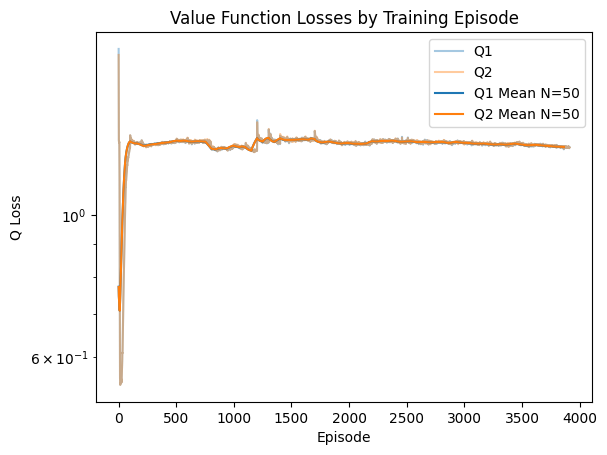

In [13]:
q_losses = np.stack([logs["Q1_loss"], logs["Q2_loss"]]).T
plot_q(q_losses, plotpath)

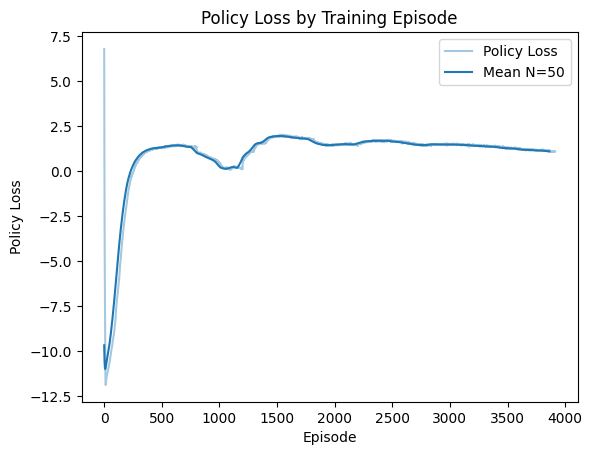

In [14]:
plot_policy_loss(logs["Policy_loss"], plotpath)

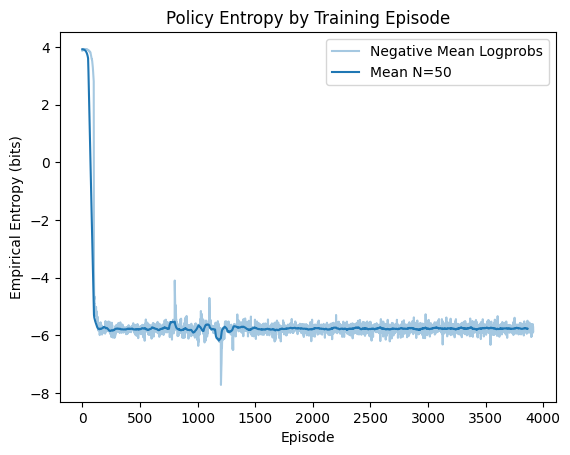

In [15]:
plot_entropy(np.asarray(logs["Logprobs"]), plotpath)

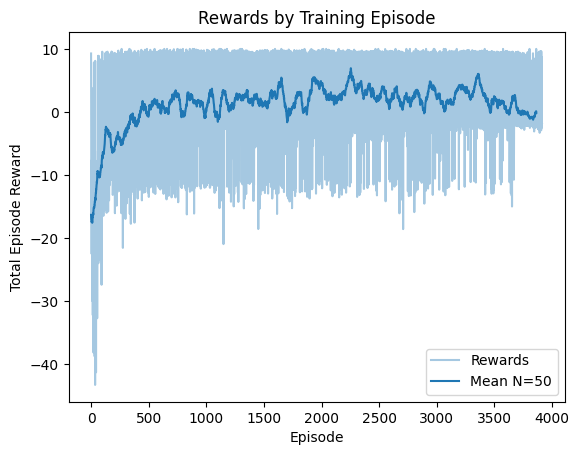

In [16]:
plot_rewards(logs["Rewards"], plotpath)

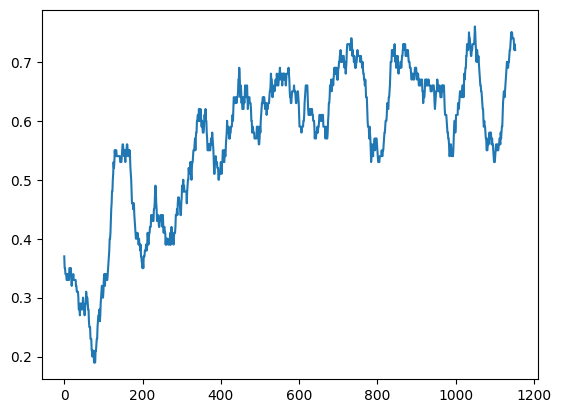

In [24]:
plt.plot(running_mean(0.5*(np.asarray(logs["Scores"])+1), 50))

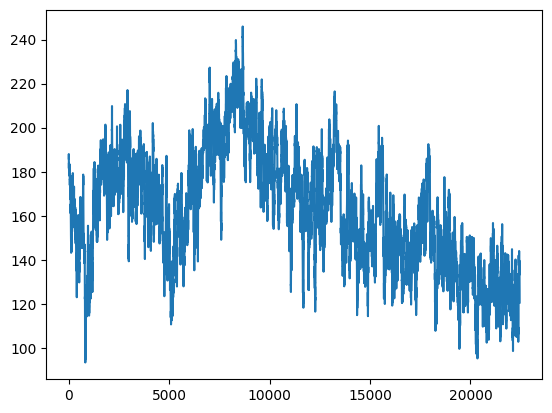

In [23]:
plt.plot(running_mean(trainer.logs["Lengths"], 50))

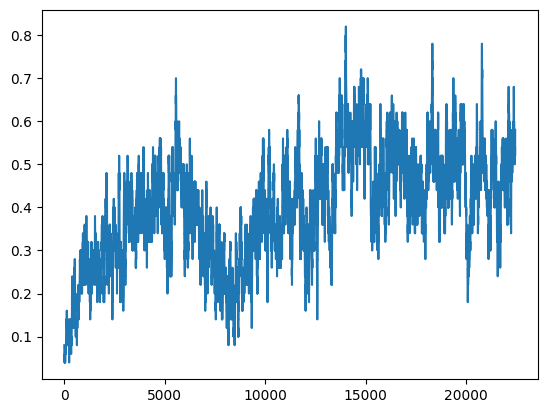

In [24]:
plt.plot(running_mean(np.asarray(trainer.logs["Scores"]) == 1, 50))